In [1]:
import pandas as pd
from data_analysis_utils import Univariate
import seaborn as sns
sns.set_style('whitegrid')


In [2]:
dataset = pd.read_csv("PrePlacement.csv")
dataset.drop('sl_no', axis=1, inplace=True)
dataset


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [3]:
dataset.isnull().sum()


gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

### Covariance

In [4]:
quan, qual = Univariate.quanQual(dataset)

dataset[quan].cov()


,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,117.228377,58.853253,42.702550,37.659225,24.535952,9.088585e+05
hsc_p,58.853253,112.063731,33.684453,33.838355,21.517688,7.310079e+05
degree_p,42.702550,33.684453,53.604710,22.078774,17.185200,4.663363e+05
etest_p,37.659225,33.838355,22.078774,176.251018,16.886973,3.727004e+05
mba_p,24.535952,21.517688,17.185200,16.886973,34.028376,1.239934e+05
salary,908858.485818,731007.850848,466336.264888,372700.449468,123993.387361,2.259185e+10


In [5]:
# Covariance between degree_p and etest_p
dataset[['degree_p', 'etest_p']].cov()

# Var(degree_p) = 53.60 → degree_p values deviate from their mean with variance ~53.6.
# Var(etest_p) = 176.25 → etest_p has much larger variance — meaning its values are more spread out

# Covariance between degree_p and etest_p is positive (22.078774), so when degree_p increases, etest_p tends to increase too (and vice versa).


,degree_p,etest_p
degree_p,53.604710,22.078774
etest_p,22.078774,176.251018


In [6]:
# Covariance between mba_p and etest_p
dataset[['mba_p', 'etest_p']].cov()

# Var(mba_p) = 34.02 → mba_p values deviate from their mean with variance ~34.02.
# Var(etest_p) = 176.25 → etest_p has much larger variance — meaning its values are more spread out

# Covariance between mba_p and etest_p is positive (16.886973), so when mba_p increases, etest_p tends to increase too (and vice versa).


,mba_p,etest_p
mba_p,34.028376,16.886973
etest_p,16.886973,176.251018


### Correlation

In [7]:
dataset[quan].corr()


,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.513478,0.538686,0.261993,0.388478,0.558475
hsc_p,0.513478,1.000000,0.434606,0.240775,0.348452,0.459424
degree_p,0.538686,0.434606,1.000000,0.227147,0.402376,0.423762
etest_p,0.261993,0.240775,0.227147,1.000000,0.218055,0.186775
mba_p,0.388478,0.348452,0.402376,0.218055,1.000000,0.141417
salary,0.558475,0.459424,0.423762,0.186775,0.141417,1.000000


In [8]:
# Correlation between mba_p and salary
dataset[['mba_p', 'salary']].corr()

# This means there is a weak positive correlation between mba_p and salary, means lots of variation in salary that’s unrelated to MBA score.


,mba_p,salary
mba_p,1.000000,0.141417
salary,0.141417,1.000000


### Multi Collinearity



In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculating VIF
def calc_vif(X):

    vif = pd.DataFrame()
    
    # Create empty dataframe vif and column 'variables' to store the column names
    
    vif["variables"] = X.columns

    # Create column 'VIF' and calculate VIF for each feature
    # X.values converts dataframe to numpy array.
    # The for loop loops for each column in dataset, then that is used to calculate VIF and returned as list in vif dataframe
    
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

# Use only quantitative columns for VIF calculation
# Removing the output variable - using only input variables to check Multi Collinearity
quan.remove('salary')

calc_vif(dataset[quan])


# VIF > 10 → Potential problem; strong multicollinearity.
# VIF between 5 and 10 → Possible concern.
# VIF < 5 → Usually fine.

# The result shows that all input features have high VIF values, indicating potential multicollinearity issues.


,variables,VIF
0,ssc_p,67.087602
1,hsc_p,59.100713
2,degree_p,114.085694
3,etest_p,32.704858
4,mba_p,99.767641


Ways to remove multi collinearity:

1. Remove redundant variables
If two variables are telling almost the same story, drop one. Using the highest ones first

In [10]:
quan.remove('degree_p')
calc_vif(dataset[quan])


,variables,VIF
0,ssc_p,58.772895
1,hsc_p,56.420306
2,etest_p,32.091188
3,mba_p,70.874469


In [11]:
quan.remove('mba_p')
calc_vif(dataset[quan])


,variables,VIF
0,ssc_p,48.578843
1,hsc_p,47.552000
2,etest_p,27.084097


In [12]:
quan.remove('ssc_p')
calc_vif(dataset[quan])

# The result shows I can use hsc_p or etest_p since both has same VIF values.


,variables,VIF
0,hsc_p,23.134453
1,etest_p,23.134453



2. Combine correlated variables
Merge them into a single variable (e.g., average of scores, or a weighted index).

Example: Create an “overall_academic_score” from ssc_p, hsc_p, and degree_p.



In [13]:
dataset['overall_academic_score'] = dataset[['ssc_p', 'hsc_p', 'degree_p']].mean(axis=1)


In [14]:
data_vif = dataset[['overall_academic_score', 'mba_p', 'etest_p']]

calc_vif(data_vif)

# The result shows the multicollinearity has reduced when compared to initial analysis.


,variables,VIF
0,overall_academic_score,90.356407
1,mba_p,89.265958
2,etest_p,32.626720


3. Transform variables with PCA (Principal Component Analysis)
PCA turns correlated variables into a smaller set of uncorrelated components.

4. Use regularization techniques
Ridge Regression: Adds a penalty to large coefficients, which helps handle collinearity.

Lasso Regression: Can actually zero out redundant variables.

5. Collect more data
More observations can make correlations less problematic by giving the model more information.

6. Change the model
Use Partial Least Squares (PLS), Decision Trees, or other algorithms less sensitive to multicollinearity.

### Homoscedasticity and Heteroscedasticity

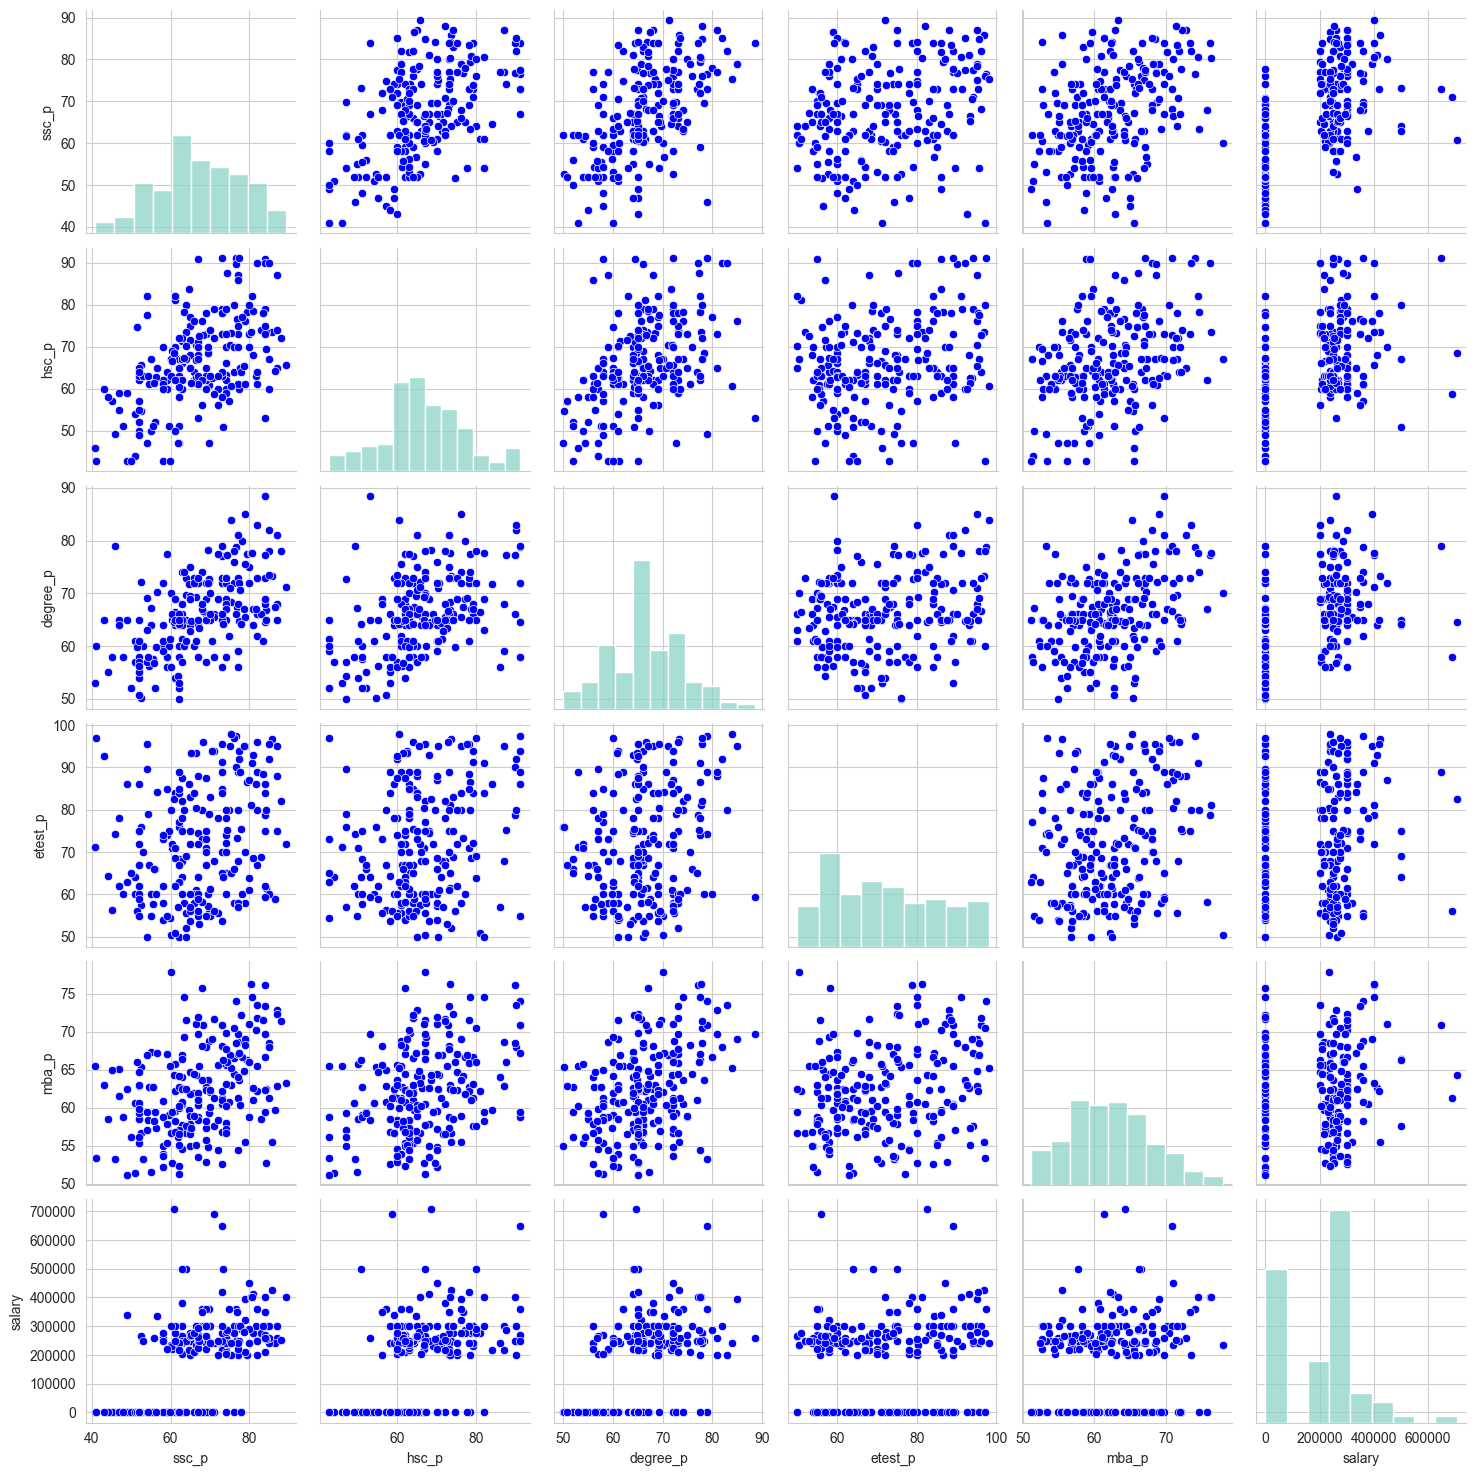

In [15]:
dataset = pd.read_csv("PrePlacement.csv")
dataset.drop('sl_no', axis=1, inplace=True)

quan, qual = Univariate.quanQual(dataset)
sns.pairplot(dataset[quan], plot_kws={'color':'blue'})


# From plot, ssc_p, hsc_p, degree_p, mba_p, variance is fairly constant → mostly homoscedastic.

# When etest_p with ssc_p, hsc_p, degree_p, mba_p pair, spread changes more noticeably → heteroscedastic tendencies.


1. Definition
Homoscedasticity: Data spread (variance) stays about the same across all values.
Heteroscedasticity: Data spread changes (gets bigger or smaller) across values.

2. Why It Matters
Homoscedasticity keeps regression results accurate.
Heteroscedasticity can make standard errors and p-values wrong.

3. How to Identify
Visual: Plot residuals vs. fitted values — random cloud = homo, funnel shape = hetero.

4. Thumb Rules
Homoscedasticity = fine for OLS.
If heteroscedastic: transform data, or use weighted regression.

5. Which Is Better
Data can be either — Neither is “good” or “bad” in nature.
For standard OLS, homoscedasticity is preferred.



### T-Test

Unpaired - Different group ( categorical ), same condition ( numerical )

In [16]:
from scipy.stats import ttest_ind
dataset=dataset.dropna()
male = dataset[dataset['gender']=='M']['salary']
female = dataset[dataset['gender']=='F']['salary']

ttest_ind(male, female)

# The result shows pvalue < 0.05, indicating a significant difference in salaries between male and female students.


TtestResult(statistic=np.float64(2.0937842507001165), pvalue=np.float64(0.03746230397067219), df=np.float64(213.0))

#### Dependant Sample-Paired T_Test

Same Group (Categorical) but Different Condition ( numerical )

In [17]:
from scipy.stats import ttest_rel
#dataset=dataset.dropna()
male = dataset[dataset['gender']=='M']['ssc_p']
male1 = dataset[dataset['gender']=='M']['hsc_p']
ttest_rel(male, male1)

# The result shows pvalue > 0.05, indicating no significant difference in male students' scores between SSC and HSC.


TtestResult(statistic=np.float64(0.6842940392688153), pvalue=np.float64(0.4949370716000775), df=np.int64(138))

In [18]:
# T Test for hsc_b - Central vs Others

central = dataset[dataset['hsc_b'] == 'Central']['salary']
others = dataset[dataset['hsc_b'] != 'Others']['salary']

ttest_ind(central, others)

# The result shows pvalue > 0.05, indicating no significant difference in salaries between Central and Other students.


TtestResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), df=np.float64(166.0))

In [19]:
# Commerce students vs Science students mba_p
# UnPaired T-Test
commerce = dataset[dataset['hsc_s'] == 'Commerce']['mba_p']
science = dataset[dataset['hsc_s'] == 'Science']['mba_p']

print(ttest_ind(commerce, science))

# The result shows pvalue (0.46432995253854314) > 0.05, indicating no significant difference in MBA scores between Commerce and Science students.

# Commerce students, mba_p vs etest_p
# Paired T-Test
mba = dataset[dataset['hsc_s'] == 'Commerce']['mba_p']
etest = dataset[dataset['hsc_s'] == 'Commerce']['etest_p']

print(ttest_rel(mba, etest))

# The result shows pvalue (2.462926468454984e-12) < 0.05, indicating a significant difference between MBA scores and E-test scores in Commerce students.


TtestResult(statistic=np.float64(-0.7331285580404581), pvalue=np.float64(0.46432995253854314), df=np.float64(202.0))
TtestResult(statistic=np.float64(-7.868552092606871), pvalue=np.float64(2.462926468454984e-12), df=np.int64(112))



### Here are 5 problem statements to test with hypothesis testing:



In [20]:
# 1. MBA Specialisation vs Salary
# Null Hypothesis - Candidates with different MBA specialisations (“Mkt&HR” vs “Mkt&Fin”) have no significant difference in average salaries
# Alternative Hypothesis - Candidates with different MBA specialisations (“Mkt&HR” vs “Mkt&Fin”) have a significant difference in average salaries

dataset['specialisation'].value_counts()

mkt_fin = dataset[dataset['specialisation'] == "Mkt&Fin"]['salary']
mkt_hr = dataset[dataset['specialisation'] == "Mkt&HR"]['salary']

test = ttest_ind(mkt_fin, mkt_hr)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect)..')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect)..')

# Result shows a p-value of < 0.05, indicating significant difference in salaries.
# So, we reject the null hypothesis.


TtestResult(statistic=np.float64(4.215962538857999), pvalue=np.float64(3.67589294322053e-05), df=np.float64(213.0))

p-value: 0.0 hence, we reject the null hypothesis (significant effect)..


In [21]:
# 2. Work Experience vs Salary

# Null Hypothesis: There is no significant difference in average salary between candidates with prior work experience and those without
# Alternative Hypothesis: There is a significant difference in average salary between candidates with prior work experience and those without

dataset['workex'].value_counts()

exp = dataset[dataset['workex'] == 'No']['salary']
no_exp = dataset[dataset['workex'] == 'Yes']['salary']

test = ttest_ind(exp, no_exp)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect)..')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect)..')


TtestResult(statistic=np.float64(-4.542053238714993), pvalue=np.float64(9.322175474152742e-06), df=np.float64(213.0))

p-value: 0.0 hence, we reject the null hypothesis (significant effect)..


In [22]:
# 3.  MBA Percentage vs Work Experience

# Null Hypothesis : There is no significant difference between MBA percentage and whether candidates have work experience or not
# Alternative Hypothesis: There is a significant difference between MBA percentage and whether candidates have work experience or not

workexp = dataset[dataset['workex'] == 'Yes']['mba_p']
no_workexp = dataset[dataset['workex'] == 'No']['mba_p']

test = ttest_ind(workexp, no_workexp)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect)..')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect)..')


TtestResult(statistic=np.float64(2.4995959488981003), pvalue=np.float64(0.013188161289746831), df=np.float64(213.0))

p-value: 0.013 hence, we reject the null hypothesis (significant effect)..


In [23]:
# 4. MBA Percentage vs Degree Percentage for working professionals

# Null Hypothesis: There is no significant difference between MBA percentage and Degree percentage for working professionals
# Alternative Hypothesis: There is a significant difference between MBA percentage and Degree percentage for working professionals

mba = dataset[dataset['workex'] == 'Yes']['mba_p']
degree = dataset[dataset['workex'] == 'Yes']['degree_p']

test = ttest_rel(mba, degree)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect)..')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect)..')


TtestResult(statistic=np.float64(-4.8160258698476275), pvalue=np.float64(7.715834733895986e-06), df=np.int64(73))

p-value: 0.0 hence, we reject the null hypothesis (significant effect)..


In [24]:
# 5. MBA Percentage vs Degree Percentage for non-working professionals

# Null Hypothesis: There is no significant difference between MBA percentage and Degree percentage for non-working professionals
# Alternative Hypothesis: There is a significant difference between MBA percentage and Degree percentage for non-working professionals

mba = dataset[dataset['workex'] == 'No']['mba_p']
degree = dataset[dataset['workex'] == 'No']['degree_p']

test = ttest_rel(mba, degree)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect)..')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect)..')


TtestResult(statistic=np.float64(-6.614297624118837), pvalue=np.float64(7.305636417898712e-10), df=np.int64(140))

p-value: 0.0 hence, we reject the null hypothesis (significant effect)..


### ANOVA

In [25]:
import scipy.stats as stats

stats.f_oneway(dataset['ssc_p'],dataset['hsc_p'],dataset['degree_p'])


F_onewayResult(statistic=np.float64(0.695991304348204), pvalue=np.float64(0.4989557472581533))



### One-Way ANOVA Hypotheses and Two-Way ANOVA Hypothesis



In [26]:
# 1. Degree Type vs Salary

# Null Hypothesis: There is no significant difference between different Degree Type and Salary
# Alternative Hypothesis: There is a significant difference between different Degree Type and Salary

import scipy.stats as stats

dataset['degree_t'].value_counts()

comm_mgmt = dataset[dataset['degree_t'] == 'Comm&Mgmt']['salary']
sci_tech = dataset[dataset['degree_t'] == 'Sci&Tech']['salary']
others = dataset[dataset['degree_t'] == 'Others']['salary']

test = stats.f_oneway(comm_mgmt, sci_tech, others)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect)..')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect)..')


F_onewayResult(statistic=np.float64(1.822212678358234), pvalue=np.float64(0.16419059641867673))

p-value: 0.164 hence, we fail to reject the null hypothesis (no significant effect)..


In [27]:
# 2. HSC Specialisation vs MBA Percentage

# Null Hypothesis: There is no significant difference between different HSC Specialisation and MBA Percentage
# Alternative Hypothesis: There is a significant difference between different HSC Specialisation and MBA Percentage

dataset['hsc_s'].value_counts()
# dataset.columns

comm_mgmt = dataset[dataset['hsc_s'] == 'Commerce']['mba_p']
sci_tech = dataset[dataset['hsc_s'] == 'Science']['mba_p']
others = dataset[dataset['hsc_s'] == 'Arts']['mba_p']

test = stats.f_oneway(comm_mgmt, sci_tech, others)

print(test)
if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (significant effect).')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (no significant effect).')


F_onewayResult(statistic=np.float64(0.2664227347184184), pvalue=np.float64(0.7663713172687727))

p-value: 0.766 hence, we fail to reject the null hypothesis (no significant effect).


In [28]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 3. Gender × Work Experience vs Salary

# Null Hypothesis: There is no significant interaction effect between Gender and Work Experience on Salary
# Alternative Hypothesis: There is a significant interaction effect between Gender and Work Experience on Salary

model = ols('salary ~ C(gender) + C(workex) + C(gender):C(workex)', data=dataset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

for factor in anova_table.index[:-1]:  # exclude 'Residual'
    p_value = anova_table.loc[factor, "PR(>F)"]
    if p_value < 0.05:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Reject null hypothesis (significant effect).")
    else:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Fail to reject null hypothesis (no significant effect).")



                           sum_sq     df          F    PR(>F)
C(gender)            6.633034e+10    1.0   3.223770  0.074007
C(workex)            3.957454e+11    1.0  19.233916  0.000018
C(gender):C(workex)  2.065377e+06    1.0   0.000100  0.992016
Residual             4.341408e+12  211.0        NaN       NaN

For C(gender), p-value = 0.074, hence we Fail to reject null hypothesis (no significant effect).

For C(workex), p-value = 0.000, hence we Reject null hypothesis (significant effect).

For C(gender):C(workex), p-value = 0.992, hence we Fail to reject null hypothesis (no significant effect).


In [29]:
# 3. Degree Type × Specialisation vs Salary

# Null Hypothesis : There is no significant interaction effect between Degree Type and Specialisation on Salary
# Alternative Hypothesis: There is a significant interaction effect between Degree Type and Specialisation on Salary

model = ols('salary ~ C(degree_t) + C(specialisation) + C(degree_t):C(specialisation)', data=dataset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

for factor in anova_table.index[:-1]:  # exclude 'Residual'
    p_value = anova_table.loc[factor, "PR(>F)"]
    if p_value < 0.05:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Reject null hypothesis (significant effect).")
    else:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Fail to reject null hypothesis (no significant effect).")



                                     sum_sq     df          F    PR(>F)
C(degree_t)                    7.480021e+10    2.0   1.786360  0.170118
C(specialisation)              3.654610e+11    1.0  17.455702  0.000043
C(degree_t):C(specialisation)  1.176281e+10    2.0   0.280917  0.755376
Residual                       4.375725e+12  209.0        NaN       NaN

For C(degree_t), p-value = 0.170, hence we Fail to reject null hypothesis (no significant effect).

For C(specialisation), p-value = 0.000, hence we Reject null hypothesis (significant effect).

For C(degree_t):C(specialisation), p-value = 0.755, hence we Fail to reject null hypothesis (no significant effect).


In [30]:
# 5. Gender X HSC Board Vs etest Percentage

# Null Hypothesis : There is no significant difference in etest percentage between different genders across HSC boards
# Alternative Hypothesis: There is a significant difference in etest percentage between different genders across HSC boards

model = ols('etest_p ~ C(gender) + C(hsc_b) + C(gender):C(hsc_b)', data=dataset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

for factor in anova_table.index[:-1]:  # exclude 'Residual'
    p_value = anova_table.loc[factor, "PR(>F)"]
    if p_value < 0.05:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Reject null hypothesis (significant effect).")
    else:
        print(f"\nFor {factor}, p-value = {p_value:.3f}, hence we Fail to reject null hypothesis (no significant effect).")



                          sum_sq     df         F    PR(>F)
C(gender)             252.951303    1.0  1.447419  0.230291
C(hsc_b)               42.638857    1.0  0.243985  0.621856
C(gender):C(hsc_b)    532.677824    1.0  3.048050  0.082290
Residual            36874.401888  211.0       NaN       NaN

For C(gender), p-value = 0.230, hence we Fail to reject null hypothesis (no significant effect).

For C(hsc_b), p-value = 0.622, hence we Fail to reject null hypothesis (no significant effect).

For C(gender):C(hsc_b), p-value = 0.082, hence we Fail to reject null hypothesis (no significant effect).
